In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from google.colab import files

uploaded = files.upload()

Saving clean_retail.csv to clean_retail (2).csv


In [12]:
retail = pd.read_csv(
    "clean_retail.csv"
)

retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [13]:
retail["InvoiceDate"] = pd.to_datetime(
    retail["InvoiceDate"]
)

retail["Revenue"] = (
    retail["Quantity"] *
    retail["Price"]
)

In [14]:
snapshot_date = (
    retail["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [15]:
rfm = retail.groupby(
    "Customer ID"
).agg(
    {
        "InvoiceDate":
            lambda x: (
                snapshot_date -
                x.max()
            ).days,

        "Invoice":
            "nunique",

        "Revenue":
            "sum"
    }
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [16]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [17]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    +
    rfm["F_Score"].astype(str)
    +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,2,0.00,1,2,1,121
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [18]:
def segment_customer(row):

    if row["RFM_Score"] == "444":
        return "VIP"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Regular"

rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [19]:
rfm["Segment"].value_counts()

,count
Segment,
Regular,2186
Loyal,1036
At Risk,654
VIP,496


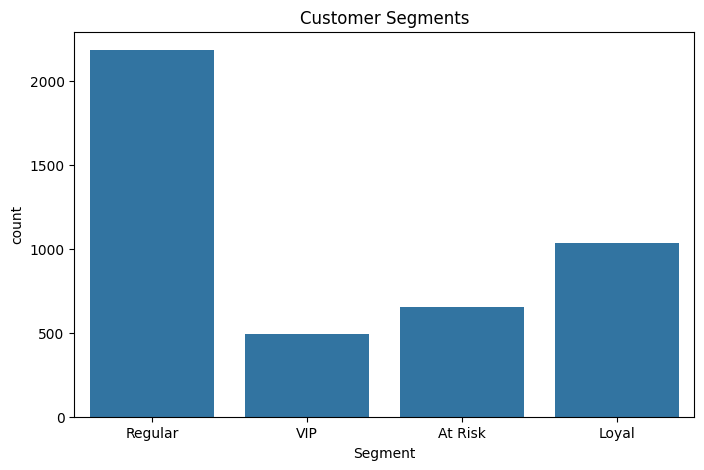

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Segment",
    data=rfm
)

plt.title(
    "Customer Segments"
)

plt.show()

In [21]:
segment_revenue = rfm.groupby(
    "Segment"
)["Monetary"].sum()

segment_revenue

,Monetary
Segment,
At Risk,942329.932
Loyal,2030713.131
Regular,944946.561
VIP,4360547.800


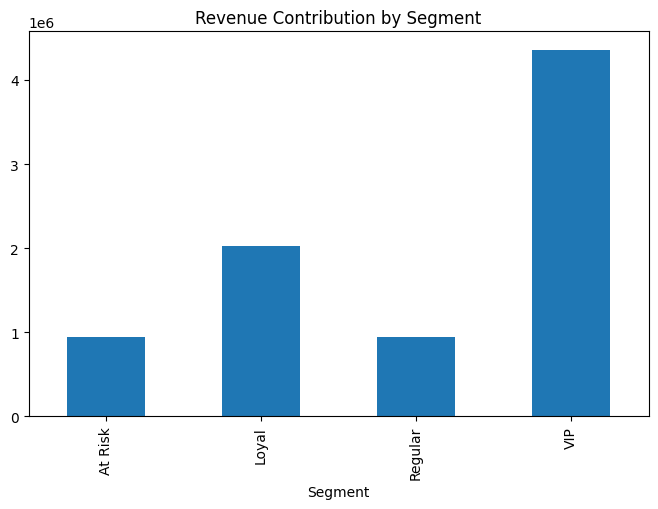

In [22]:
plt.figure(figsize=(8,5))

segment_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue Contribution by Segment"
)

plt.show()

In [23]:
vip_customers = rfm[
    rfm["Segment"] == "VIP"
]

vip_customers.head(20)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12347.0,2,7,4310.00,4,4,4,444,VIP
12359.0,8,6,6182.98,4,4,4,444,VIP
12362.0,3,13,5154.58,4,4,4,444,VIP
12381.0,5,6,1803.96,4,4,4,444,VIP
12388.0,16,6,2780.66,4,4,4,444,VIP
12395.0,16,15,2998.28,4,4,4,444,VIP
12417.0,3,12,3578.80,4,4,4,444,VIP
12423.0,1,9,1849.11,4,4,4,444,VIP
12433.0,1,7,13375.87,4,4,4,444,VIP


In [24]:
rfm.to_csv(
    "customer_segments.csv"
)

print(
    "Customer Segments Saved"
)

Customer Segments Saved


In [25]:
from google.colab import files

files.download(
    "customer_segments.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>